Experiment IDs to indicate which environment to run
1. ID 1 = CartPole-v1    + DQN
2. ID 2 = CartPole-v1    + Double DQN 
3. ID 3 = LunarLander-v3 + DQN 
4. ID 4 = LunarLander-v3 + Double DQN

## Imports

In [1]:
import copy
import random
from collections import deque

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

## Reproducibility and Device Setting

In [2]:
SEED = 42


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SAVE_MODEL = True
SAVE_RESULTS = True
SHOW_PLOTS = True

## Hyperparameters

In [3]:
EXPERIMENTS = {
    1: {
        "environment": "CartPole-v1",
        "algorithm": "DQN",
        "config": {
            "episodes": 2000,
            "learning_rate": 0.00005,
            "gamma": 0.99,
            "batch_size": 64,
            "replay_buffer_size": 50000,
            "minimum_replay_size": 1000,
            "target_update_frequency": 1000,
            "train_frequency": 1,
            "epsilon_start": 1.0,
            "epsilon_end": 0.02,
            "epsilon_decay_steps": 15000,
            "hidden_layers": [128, 128],
            "gradient_clip": 10.0,
            "evaluation_episodes": 20,
            "success_reward": 475,
        },
    },
    2: {
        "environment": "CartPole-v1",
        "algorithm": "DoubleDQN",
        "config": {
            "episodes": 4000,
            "learning_rate": 0.00005,
            "gamma": 0.99,
            "batch_size": 64,
            "replay_buffer_size": 50000,
            "minimum_replay_size": 1000,
            "target_update_frequency": 1000,
            "train_frequency": 1,
            "epsilon_start": 1.0,
            "epsilon_end": 0.01,
            "epsilon_decay_steps": 50000,
            "hidden_layers": [128, 128, 128],
            "gradient_clip": 10.0,
            "evaluation_episodes": 20,
            "success_reward": 475,
        },
    },
    3: {
        "environment": "LunarLander-v3",
        "algorithm": "DQN",
        "config": {
            "episodes": 3000,
            "learning_rate": 0.00005,
            "gamma": 0.99,
            "batch_size": 64,
            "replay_buffer_size": 100000,
            "minimum_replay_size": 2000,
            "target_update_frequency": 1000,
            "train_frequency": 1,
            "epsilon_start": 1.0,
            "epsilon_end": 0.01,
            "epsilon_decay_steps": 150000,
            "hidden_layers": [256, 256],
            "gradient_clip": 10.0,
            "evaluation_episodes": 50,
            "success_reward": 200
        },
    },
    4: {
        "environment": "LunarLander-v3",
        "algorithm": "DoubleDQN",
        "config": {
            "episodes": 3000,
            "learning_rate": 0.0005,
            "gamma": 0.99,
            "batch_size": 64,
            "replay_buffer_size": 100000,
            "minimum_replay_size": 2000,
            "target_update_frequency": 1000,
            "train_frequency": 1,
            "epsilon_start": 1.0,
            "epsilon_end": 0.01,
            "epsilon_decay_steps": 150000,
            "hidden_layers": [256, 256],
            "gradient_clip": 10.0,
            "evaluation_episodes": 50,
            "success_reward": 200,
        },
    },
}

## Create and Validate Environment

In [4]:
def create_environment(environment_name, render_mode=None):
    if render_mode is None:
        return gym.make(environment_name)
    return gym.make(environment_name, render_mode=render_mode)


def validate_environment(env):
    if not isinstance(env.action_space, gym.spaces.Discrete):
        raise ValueError("DQN and Double DQN require a discrete action space.")
    if not isinstance(env.observation_space, gym.spaces.Box):
        raise ValueError("This implementation requires a Box observation space.")
    state_size = int(np.prod(env.observation_space.shape))
    action_size = env.action_space.n
    return state_size, action_size

## Replay Buffer

In [5]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def add(self, state, action, reward, next_state, terminated, truncated):
        self.buffer.append((state, action, reward, next_state, terminated, truncated))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states = np.asarray([x[0] for x in batch], dtype=np.float32)
        actions = np.asarray([x[1] for x in batch], dtype=np.int64)
        rewards = np.asarray([x[2] for x in batch], dtype=np.float32)
        next_states = np.asarray([x[3] for x in batch], dtype=np.float32)
        terminated = np.asarray([x[4] for x in batch], dtype=np.float32)
        truncated = np.asarray([x[5] for x in batch], dtype=np.float32)
        return (states, actions, rewards, next_states, terminated, truncated)

    def __len__(self):
        return len(self.buffer)

## DQN and Double-DQN Related Definitions

In [6]:
class QNetwork(nn.Module):
    def __init__(self, state_size, action_size, hidden_layers):
        super().__init__()
        layers = []
        input_size = state_size
        for hidden_size in hidden_layers:
            layers.append(nn.Linear(input_size, hidden_size))
            layers.append(nn.ReLU())
            input_size = hidden_size

        layers.append(nn.Linear(input_size, action_size))
        self.network = nn.Sequential(*layers)

    def forward(self, state):
        return self.network(state)


# Common components shared by DQN and Double DQN.
class BaseDQNAgent:
    def __init__(self, state_size, action_size, config):
        self.state_size = state_size
        self.action_size = action_size
        self.gamma = config["gamma"]
        self.batch_size = config["batch_size"]
        self.learning_rate = config["learning_rate"]
        self.minimum_replay_size = config["minimum_replay_size"]
        self.target_update_frequency = config["target_update_frequency"]
        self.train_frequency = config["train_frequency"]
        self.epsilon_start = config["epsilon_start"]
        self.epsilon_end = config["epsilon_end"]
        self.epsilon_decay_steps = config["epsilon_decay_steps"]
        self.gradient_clip = config["gradient_clip"]

        # online network
        self.online_network = QNetwork(
            state_size, action_size, config["hidden_layers"]
        ).to(DEVICE)

        # target network
        self.target_network = QNetwork(
            state_size, action_size, config["hidden_layers"]
        ).to(DEVICE)

        # initially target = online
        self.target_network.load_state_dict(self.online_network.state_dict())
        self.target_network.eval()

        self.optimizer = optim.Adam(
            self.online_network.parameters(), lr=self.learning_rate
        )
        self.loss_function = nn.SmoothL1Loss()

        self.replay_buffer = ReplayBuffer(config["replay_buffer_size"])
        self.total_steps = 0
        self.training_steps = 0

    def get_epsilon(self):
        progress = min(self.total_steps / self.epsilon_decay_steps, 1.0)
        return self.epsilon_start + progress * (self.epsilon_end - self.epsilon_start)

    def select_action(self, state, training=True):
        if training:
            epsilon = self.get_epsilon()
            if random.random() < epsilon:
                return random.randrange(self.action_size)
        state_tensor = torch.as_tensor(
            state, dtype=torch.float32, device=DEVICE
        ).unsqueeze(0)
        with torch.no_grad():
            q_values = self.online_network(state_tensor)
        return torch.argmax(q_values, dim=1).item()

    def store_transition(
        self, state, action, reward, next_state, terminated, truncated
    ):
        self.replay_buffer.add(state, action, reward, next_state, terminated, truncated)

    def calculate_current_q(self, states, actions):
        q_values = self.online_network(states)
        return q_values.gather(1, actions).squeeze(1)

    def calculate_target_q(self, rewards, next_states, terminated):
        raise NotImplementedError

    def train_step(self):
        if len(self.replay_buffer) < self.batch_size:
            return None
        states, actions, rewards, next_states, terminated, truncated = (
            self.replay_buffer.sample(self.batch_size)
        )
        states = torch.as_tensor(states, dtype=torch.float32, device=DEVICE)
        actions = torch.as_tensor(actions, dtype=torch.long, device=DEVICE).unsqueeze(1)
        rewards = torch.as_tensor(rewards, dtype=torch.float32, device=DEVICE)
        next_states = torch.as_tensor(next_states, dtype=torch.float32, device=DEVICE)
        terminated = torch.as_tensor(terminated, dtype=torch.float32, device=DEVICE)
        current_q = self.calculate_current_q(states, actions)
        target_q = self.calculate_target_q(rewards, next_states, terminated)
        loss = self.loss_function(current_q, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            self.online_network.parameters(), self.gradient_clip
        )
        self.optimizer.step()
        self.training_steps += 1
        if (
            self.training_steps
            % self.target_update_frequency
            == 0
        ):
            self.update_target_network()
        return loss.item()

    def update_target_network(self):
        self.target_network.load_state_dict(self.online_network.state_dict())

    def save_model(self, filename):
        torch.save(
            {
                "online_network": self.online_network.state_dict(),
                "target_network": self.target_network.state_dict(),
                "optimizer": self.optimizer.state_dict(),
                "total_steps": self.total_steps,
                "training_steps": self.training_steps,
            },
            filename,
        )


class DQNAgent(BaseDQNAgent):
    def calculate_target_q(self, rewards, next_states, terminated):
        with torch.no_grad():
            next_q_values = self.target_network(next_states)
            max_next_q = torch.max(next_q_values, dim=1).values
        target_q = rewards + self.gamma * max_next_q * (1.0 - terminated)
        return target_q


class DoubleDQNAgent(BaseDQNAgent):
    def calculate_target_q(self, rewards, next_states, terminated):
        with torch.no_grad():
            online_next_q_values = self.online_network(next_states)
            best_actions = torch.argmax(online_next_q_values, dim=1)
            target_next_q_values = self.target_network(next_states)
            selected_target_q = target_next_q_values.gather(
                1, best_actions.unsqueeze(1)
            ).squeeze(1)
        target_q = rewards + self.gamma * selected_target_q * (1.0 - terminated)
        return target_q


def create_agent(algorithm_name, state_size, action_size, config):
    if algorithm_name == "DQN":
        print("Creating STANDARD DQN agent...")
        return DQNAgent(state_size, action_size, config)
    elif algorithm_name == "DoubleDQN":
        print("Creating DOUBLE DQN agent...")
        return DoubleDQNAgent(state_size, action_size, config)
    else:
        raise ValueError("Algorithm must be DQN or DoubleDQN.")

## Training Function

In [7]:
def train_agent(env, agent, config):
    rewards = []
    episode_lengths = []
    losses = []
    epsilons = []
    best_average_reward = -float("inf")
    best_online_state = None
    best_target_state = None

    for episode in range(1, config["episodes"] + 1):
        state, info = env.reset(seed=SEED + episode)
        state = np.asarray(state, dtype=np.float32).flatten()
        episode_reward = 0.0
        episode_length = 0
        episode_losses = []

        while True:
            action = agent.select_action(state, training=True)
            next_state, reward, terminated, truncated, info = env.step(action)
            next_state = np.asarray(next_state, dtype=np.float32).flatten()
            agent.store_transition(
                state, action, reward, next_state, terminated, truncated
            )

            if len(agent.replay_buffer) >= agent.minimum_replay_size:
                if (
                    agent.total_steps
                    % agent.train_frequency
                    == 0
                ):
                    loss = agent.train_step()
                    if loss is not None:
                        episode_losses.append(loss)

            state = next_state
            episode_reward += reward
            episode_length += 1
            agent.total_steps += 1

            if terminated or truncated:
                break

        rewards.append(episode_reward)
        episode_lengths.append(episode_length)

        if episode_losses:
            average_loss = np.mean(episode_losses)
        else:
            average_loss = np.nan

        losses.append(average_loss)
        epsilons.append(agent.get_epsilon())
        average_reward = np.mean(rewards[-100:])

        if len(rewards) >= 100 and average_reward > best_average_reward:
            best_average_reward = average_reward
            best_online_state = copy.deepcopy(agent.online_network.state_dict())
            best_target_state = copy.deepcopy(agent.target_network.state_dict())

        print(
            f"Episode {episode:4d} | "
            f"Reward {episode_reward:8.2f} | "
            f"Avg100 {average_reward:8.2f} | "
            f"Length {episode_length:4d} | "
            f"Epsilon {epsilons[-1]:.4f} | "
            f"Loss {average_loss:.6f}"
        )

    if best_online_state is not None:
        agent.online_network.load_state_dict(best_online_state)
        agent.target_network.load_state_dict(best_target_state)

    return {
        "rewards": rewards,
        "episode_lengths": episode_lengths,
        "losses": losses,
        "epsilons": epsilons,
        "best_average_reward": best_average_reward,
    }

## Evaluation Function

In [8]:
def evaluate_agent(environment_name, agent, config):
    env = create_environment(environment_name)

    evaluation_rewards = []
    evaluation_lengths = []

    for episode in range(config["evaluation_episodes"]):
        state, info = env.reset(seed=SEED + 10000 + episode)
        state = np.asarray(state, dtype=np.float32).flatten()
        total_reward = 0.0
        steps = 0

        while True:
            action = agent.select_action(state, training=False)
            next_state, reward, terminated, truncated, info = env.step(action)
            next_state = np.asarray(next_state, dtype=np.float32).flatten()
            state = next_state
            total_reward += reward
            steps += 1
            if terminated or truncated:
                break

        evaluation_rewards.append(total_reward)
        evaluation_lengths.append(steps)
    env.close()

    average_reward = np.mean(evaluation_rewards)
    reward_std = np.std(evaluation_rewards)
    average_length = np.mean(evaluation_lengths)
    threshold = config["success_reward"]
    successful_episodes = sum(reward >= threshold for reward in evaluation_rewards)
    success_rate = (successful_episodes / len(evaluation_rewards)) * 100

    print()
    print("=" * 70)
    print("FINAL EVALUATION")
    print("=" * 70)

    print(f"Experiment ID : {EXPERIMENT_ID}")
    print(f"Environment   : {ENV_NAME}")
    print(f"Algorithm     : {ALGORITHM_NAME}")
    print(f"Average Reward: {average_reward:.2f}")
    print(f"Reward Std    : {reward_std:.2f}")
    print(f"Average Length: {average_length:.2f}")
    print(f"Success Rate  : {success_rate:.2f}%")

    print("=" * 70)

    return {
        "average_reward": average_reward,
        "reward_std": reward_std,
        "average_length": average_length,
        "success_rate": success_rate,
        "episode_rewards": evaluation_rewards,
    }

## Moving Average Calculation Function

In [9]:
# used to decide the best model
def moving_average(values, window=100):
    values = np.asarray(values, dtype=np.float32)
    if len(values) < window:
        return values
    return np.convolve(values, np.ones(window) / window, mode="valid")

## Plottings

In [10]:
# rewards
def plot_rewards(rewards):
    plt.figure(figsize=(12, 6))
    plt.plot(rewards, alpha=0.30, label="Episode Reward")
    if len(rewards) >= 100:
        average = moving_average(rewards, 100)
        plt.plot(range(99, len(rewards)), average, label="100-Episode Moving Average")
        
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.title(f"{ENV_NAME} - {ALGORITHM_NAME} - Reward")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

# loss
def plot_loss(losses):
    plt.figure(figsize=(12, 6))
    plt.plot(losses)
    plt.xlabel("Episode")
    plt.ylabel("Loss")
    plt.title(f"{ENV_NAME} - {ALGORITHM_NAME} - Training Loss")
    plt.grid()
    plt.tight_layout()
    plt.show()

# epsilon
def plot_epsilon(epsilons):
    plt.figure(figsize=(12, 6))
    plt.plot(epsilons)
    plt.xlabel("Episode")
    plt.ylabel("Epsilon")
    plt.title(f"{ENV_NAME} - {ALGORITHM_NAME} - Epsilon")
    plt.grid()
    plt.tight_layout()
    plt.show()

# episode length
def plot_episode_lengths(lengths):
    plt.figure(figsize=(12, 6))
    plt.plot(lengths, alpha=0.30, label="Episode Length")
    if len(lengths) >= 100:
        average = moving_average(lengths, 100)
        plt.plot(range(99, len(lengths)), average, label="100-Episode Moving Average")

    plt.xlabel("Episode")
    plt.ylabel("Episode Length")
    plt.title(f"{ENV_NAME} - {ALGORITHM_NAME} - Episode Length")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

## Save Results and Model

In [11]:
def save_training_results(results):
    filename = f"experiment_{EXPERIMENT_ID}_results.npz"
    np.savez(
        filename,
        rewards=np.asarray(results["rewards"], dtype=np.float32),
        episode_lengths=np.asarray(results["episode_lengths"], dtype=np.int32),
        losses=np.asarray(results["losses"], dtype=np.float32),
        epsilons=np.asarray(results["epsilons"], dtype=np.float32),
        best_average_reward=np.asarray(
            results["best_average_reward"], dtype=np.float32
        ),
    )
    print(f"Results saved: {filename}")


def save_model(agent):
    safe_environment = ENV_NAME.replace("-", "_")
    filename = (
        f"experiment_{EXPERIMENT_ID}_" f"{safe_environment}_" f"{ALGORITHM_NAME}.pth"
    )
    agent.save_model(filename)
    print(f"Model saved: {filename}")

## Show the Experiment Configurations

In [12]:
def print_configuration():
    print()
    print("=" * 70)
    print("MODULAR DQN / DOUBLE DQN PROJECT")
    print("=" * 70)
    print(f"Experiment ID : {EXPERIMENT_ID}")
    print(f"Environment   : {ENV_NAME}")
    print(f"Algorithm     : {ALGORITHM_NAME}")
    print(f"Device        : {DEVICE}")
    print(f"Episodes      : {CONFIG['episodes']}")
    print(f"Learning Rate : {CONFIG['learning_rate']}")
    print(f"Gamma         : {CONFIG['gamma']}")
    print(f"Batch Size    : {CONFIG['batch_size']}")
    print(f"Replay Buffer : {CONFIG['replay_buffer_size']}")
    print(f"Hidden Layers : {CONFIG['hidden_layers']}")
    print("=" * 70)

## Experiment Run

In [13]:
def run_experiment(experiment_id):

    global EXPERIMENT_ID
    global ENV_NAME
    global ALGORITHM_NAME
    global CONFIG

    EXPERIMENT_ID = experiment_id

    if EXPERIMENT_ID not in EXPERIMENTS:
        raise ValueError("EXPERIMENT_ID must be from 1 to 4.")

    experiment = EXPERIMENTS[EXPERIMENT_ID]
    ENV_NAME = experiment["environment"]
    ALGORITHM_NAME = experiment["algorithm"]
    CONFIG = experiment["config"]

    print_configuration()
    env = create_environment(ENV_NAME)
    state_size, action_size = validate_environment(env)

    print(f"Observation Space : " f"{env.observation_space}")
    print(f"Action Space      : " f"{env.action_space}")
    print(f"State Size        : {state_size}")
    print(f"Number of Actions : {action_size}")
    print("=" * 70)

    # training
    agent = create_agent(
        algorithm_name=ALGORITHM_NAME,
        state_size=state_size,
        action_size=action_size,
        config=CONFIG,
    )

    results = train_agent(env=env, agent=agent, config=CONFIG)
    env.close()
    
    if SAVE_MODEL:
        save_model(agent)

    # evaluation
    evaluation = evaluate_agent(environment_name=ENV_NAME, agent=agent, config=CONFIG)

    if SAVE_RESULTS:
        save_training_results(results)

    # plotting
    if SHOW_PLOTS:
        plot_rewards(results["rewards"])
        plot_loss(results["losses"])
        plot_epsilon(results["epsilons"])
        plot_episode_lengths(results["episode_lengths"])

    # summary
    print()
    print("=" * 70)
    print("EXPERIMENT COMPLETE")
    print("=" * 70)
    print(f"Experiment ID  : {EXPERIMENT_ID}")
    print(f"Environment    : {ENV_NAME}")
    print(f"Algorithm      : {ALGORITHM_NAME}")
    print(f"Average Reward : " f"{evaluation['average_reward']:.2f}")
    print(f"Reward Std     : " f"{evaluation['reward_std']:.2f}")
    print(f"Average Length : " f"{evaluation['average_length']:.2f}")
    print(f"Success Rate   : " f"{evaluation['success_rate']:.2f}%")
    print(f"Best Train Avg : " f"{results['best_average_reward']:.2f}")
    print("=" * 70)

## Lunar Lander DQN


MODULAR DQN / DOUBLE DQN PROJECT
Experiment ID : 3
Environment   : LunarLander-v3
Algorithm     : DQN
Device        : cpu
Episodes      : 3000
Learning Rate : 5e-05
Gamma         : 0.99
Batch Size    : 64
Replay Buffer : 100000
Hidden Layers : [256, 256]
Observation Space : Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Action Space      : Discrete(4)
State Size        : 8
Number of Actions : 4
Creating STANDARD DQN agent...
Episode    1 | Reward  -155.97 | Avg100  -155.97 | Length   78 | Epsilon 0.9995 | Loss nan
Episode    2 | Reward  -170.73 | Avg100  -163.35 | Length   97 | Epsilon 0.9988 | Loss nan
Episode    3 | Reward  -198.12 | Avg100  -174.94 | Length   98 | Epsilon 0.9982 | Loss nan
Episode    4 | Reward  -152.52 | Avg100  -169.34 | Length   63 | Epsilon 0.9978 | Loss nan
Episode    5 | Reward  -381.90 | Avg100  -211.85 | Lengt

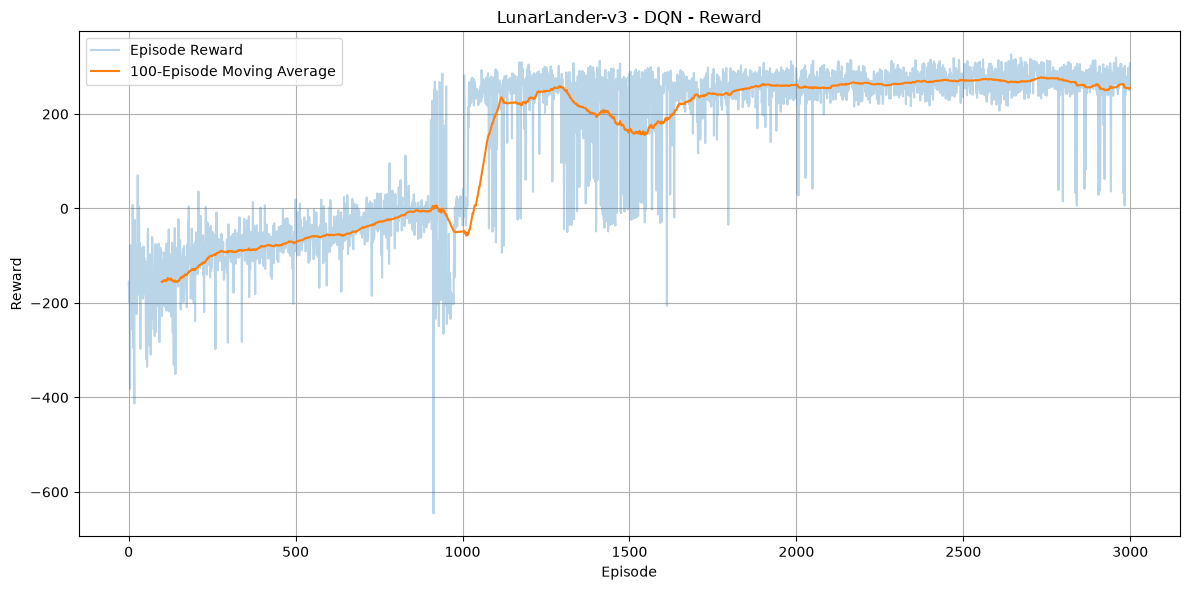

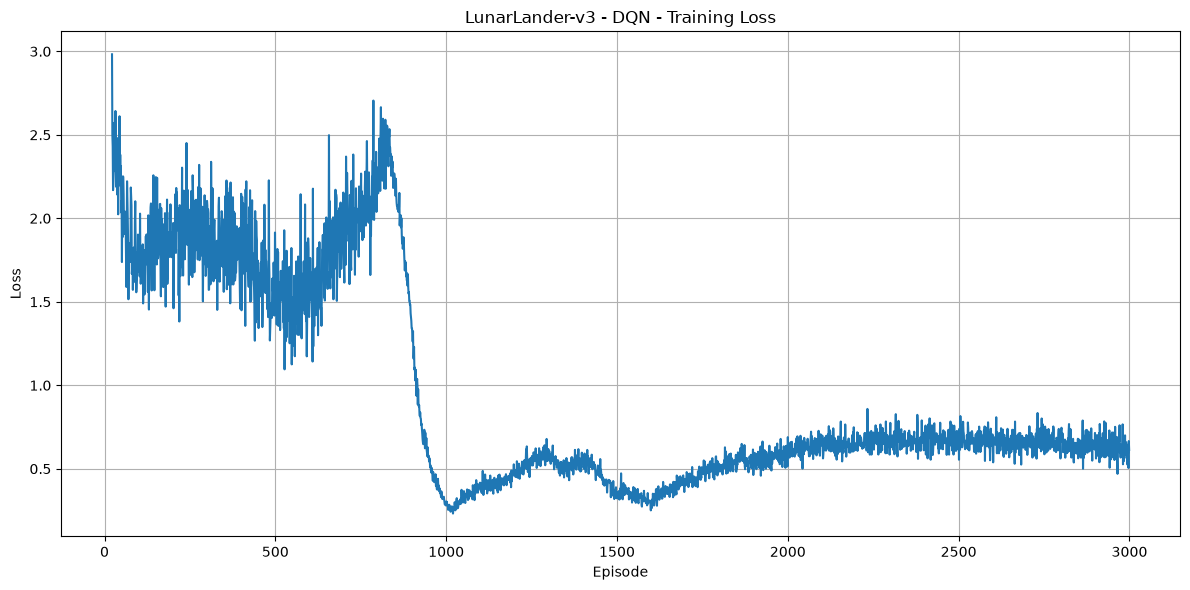

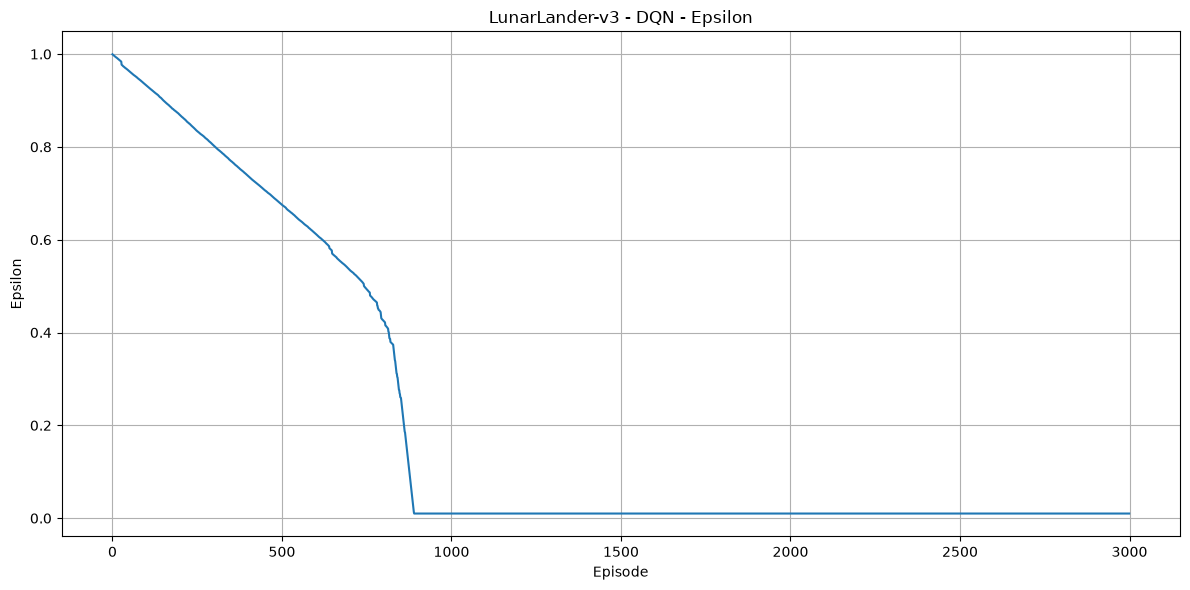

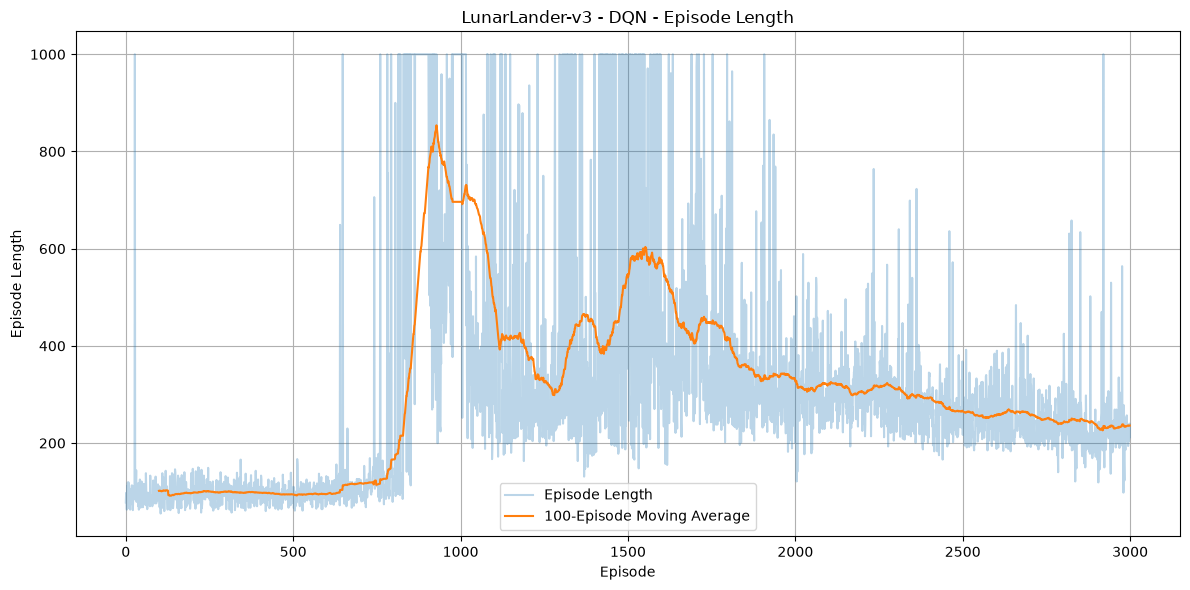


EXPERIMENT COMPLETE
Experiment ID  : 3
Environment    : LunarLander-v3
Algorithm      : DQN
Average Reward : 268.37
Reward Std     : 34.02
Average Length : 277.48
Success Rate   : 96.00%
Best Train Avg : 277.98


In [14]:
run_experiment(3)

## Lunar Lander Double-DQN


MODULAR DQN / DOUBLE DQN PROJECT
Experiment ID : 4
Environment   : LunarLander-v3
Algorithm     : DoubleDQN
Device        : cpu
Episodes      : 3000
Learning Rate : 0.0005
Gamma         : 0.99
Batch Size    : 64
Replay Buffer : 100000
Hidden Layers : [256, 256]
Observation Space : Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Action Space      : Discrete(4)
State Size        : 8
Number of Actions : 4
Creating DOUBLE DQN agent...
Episode    1 | Reward  -165.01 | Avg100  -165.01 | Length   83 | Epsilon 0.9995 | Loss nan
Episode    2 | Reward  -373.55 | Avg100  -269.28 | Length   96 | Epsilon 0.9988 | Loss nan
Episode    3 | Reward  -324.27 | Avg100  -287.61 | Length  107 | Epsilon 0.9981 | Loss nan
Episode    4 | Reward   -91.16 | Avg100  -238.50 | Length   68 | Epsilon 0.9977 | Loss nan
Episode    5 | Reward  -467.25 | Avg100  -284.25 | 

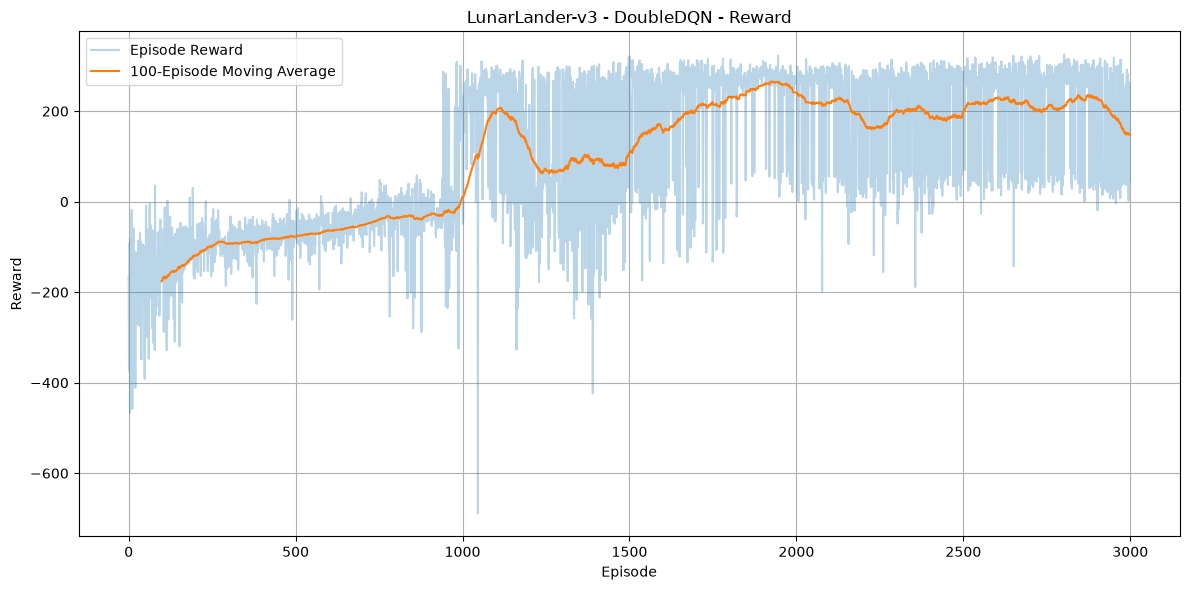

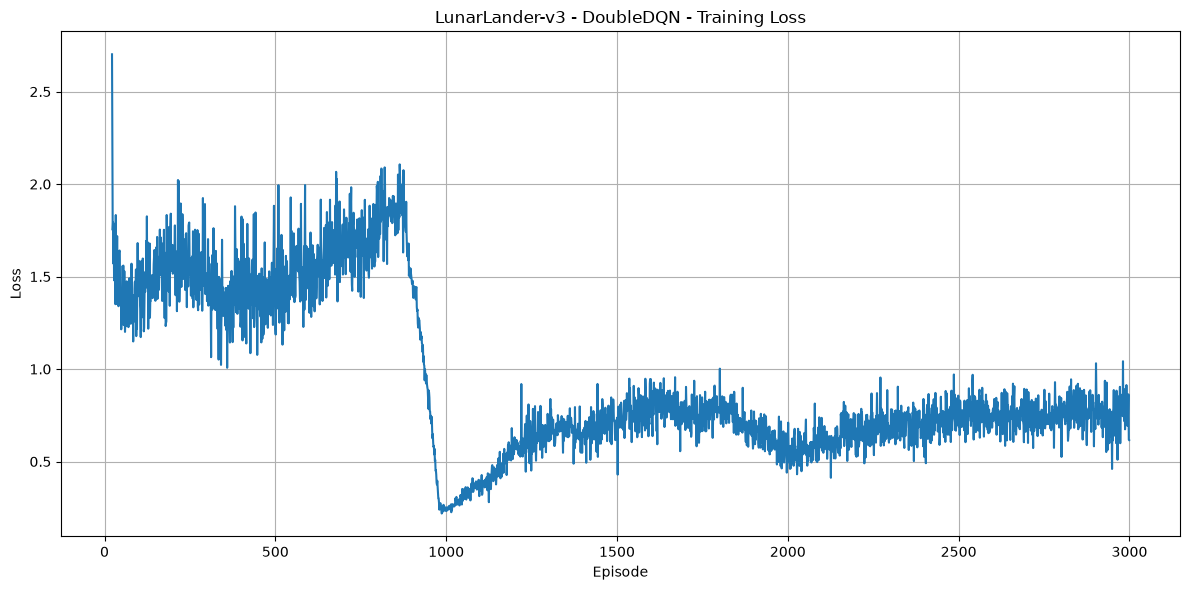

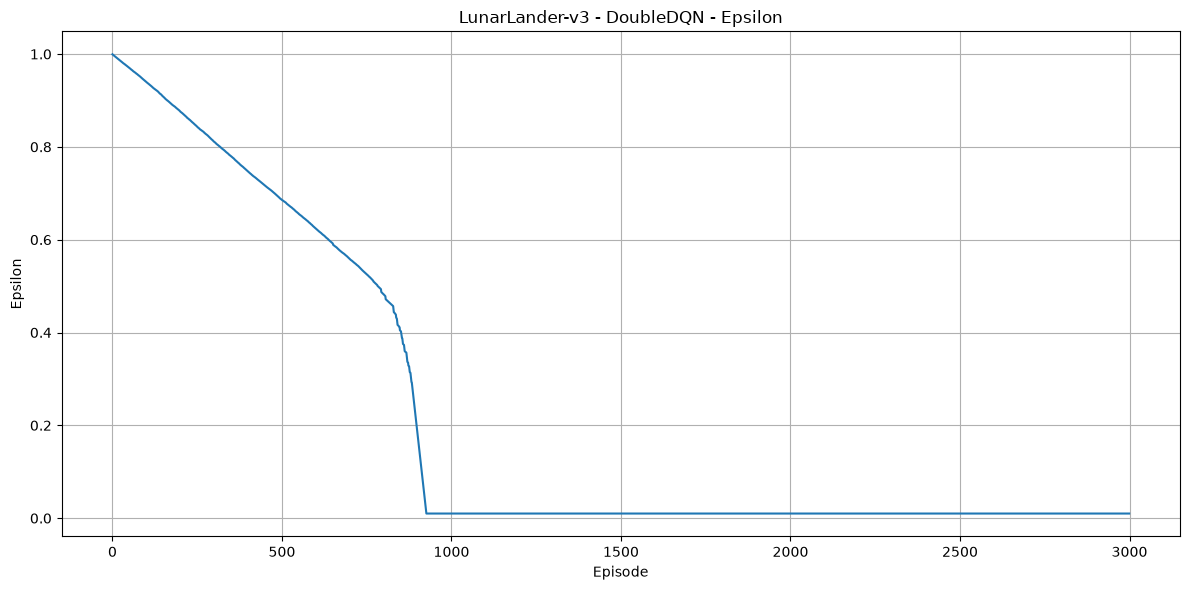

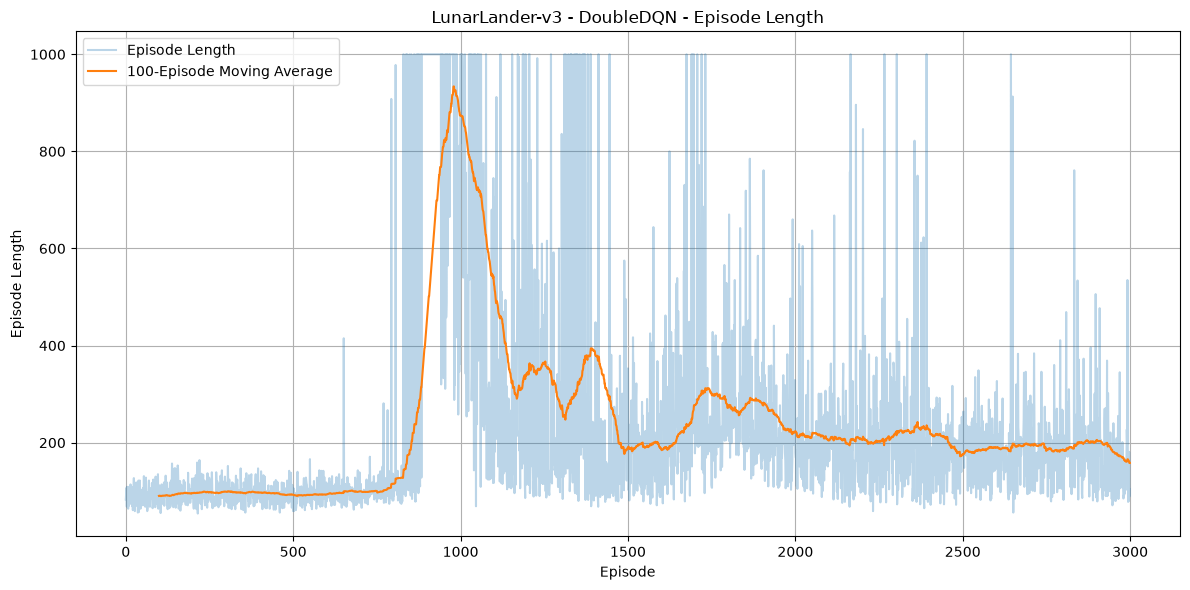


EXPERIMENT COMPLETE
Experiment ID  : 4
Environment    : LunarLander-v3
Algorithm      : DoubleDQN
Average Reward : 274.33
Reward Std     : 33.59
Average Length : 257.44
Success Rate   : 94.00%
Best Train Avg : 265.44


In [15]:
run_experiment(4)